<a href="https://colab.research.google.com/github/Sarim187/Phillips-Curve-India/blob/main/India_Phillips_curve.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Does the phillips curve hold for India?

##Introduction
The Phillips Curve describes an inverse relationship between inflation and unemployement.

##Objective
We test whether this relationship holds for India from 2000-2024

##Data description
Inflation data: World Bank,
Unemployment data: Fred's  

In [ ]:
import pandas as pd

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
#loading data inflation data
inf = pd.read_csv("/content/india_inflation_2000_2024.csv")
inf.rename(columns={"observation_date":"date","FPCPITOTLZGIND":"inf"})
print(inf.head())

   Year  Inflation_CPI_Percent
0  2000                   3.81
1  2001                   4.28
2  2002                   4.04
3  2003                   3.85
4  2004                   3.79


In [ ]:
#renaming columns
inf.rename(columns={"Inflation_CPI_Percent":"inf"}, inplace=True)

In [ ]:
#renamed column names
print(inf.head())

   Year   inf
0  2000  3.81
1  2001  4.28
2  2002  4.04
3  2003  3.85
4  2004  3.79


In [ ]:
#loading unemployment data
unemp = pd.read_csv("/content/Unemp india.csv")
print(unemp.head())

  observation_date  SLUEM1524ZSIND
0       1991-01-01          20.358
1       1992-01-01          20.437
2       1993-01-01          20.539
3       1994-01-01          20.378
4       1995-01-01          20.285


In [65]:
#renaming columns
unemp.rename(columns={"observation_date":"date","SLUEM1524ZSIND":"unem"}, inplace=True)

In [ ]:
#renamed column names
print(unemp.head())

         date    unem
0  1991-01-01  20.358
1  1992-01-01  20.437
2  1993-01-01  20.539
3  1994-01-01  20.378
4  1995-01-01  20.285


In [ ]:
#first we have changed the date format and then merged the data
inf["Year"] = inf["Year"].astype(int)
unemp["date"]=pd.to_datetime(unemp["date"]).dt.year.astype(int)
merged_data=pd.merge(inf,unemp,left_on="Year", right_on="date")
print(merged_data.head())

   Year  Inflation_CPI_Percent  date    unem
0  2000                   3.81  2000  20.273
1  2001                   4.28  2001  20.513
2  2002                   4.04  2002  20.918
3  2003                   3.85  2003  20.957
4  2004                   3.79  2004  21.047


In [ ]:
import matplotlib.pyplot as plt

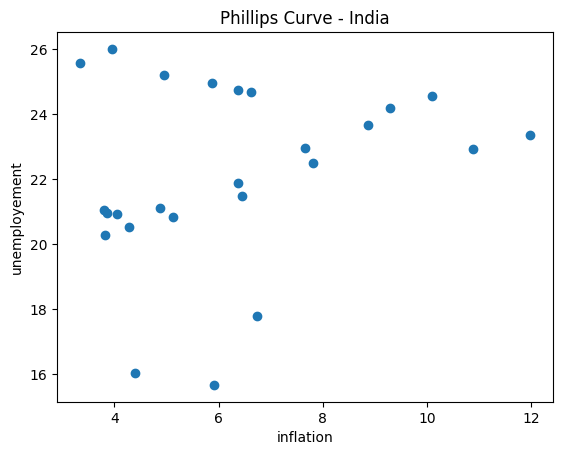

In [ ]:
#plotting the data
plt.scatter(merged_data["Inflation_CPI_Percent"],merged_data["unem"])
plt.title("Phillips Curve - India")
plt.xlabel("inflation")
plt.ylabel('unemployement')
plt.show()

In [ ]:
#Preparing Data For Regression
x =merged_data['Inflation_CPI_Percent'].values
y = merged_data['unem'].values

In [ ]:
import numpy as np

In [ ]:
#Fitting a simple linear regression line
coefficients = np.polyfit(x,y,1)
linear_fit = np.poly1d(coefficients)


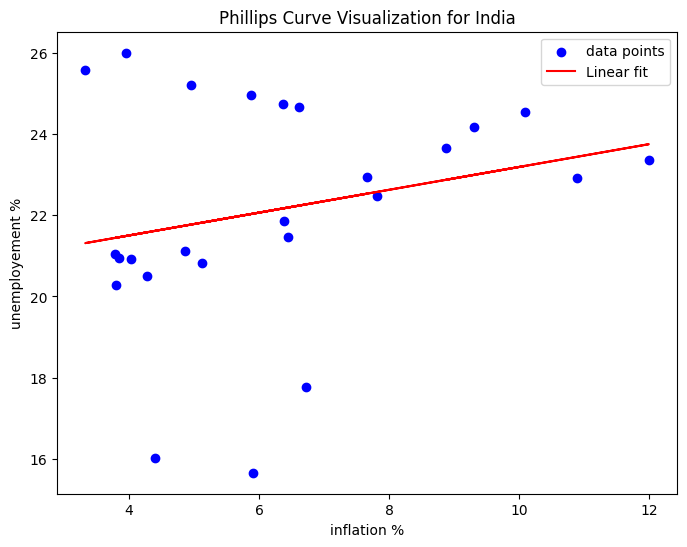

In [ ]:
#plotting the data
plt.figure(figsize=(8,6))
plt.scatter(x,y, color='blue', label='data points')
plt.plot(x, linear_fit(x), color='red', label='Linear fit')
plt.xlabel('inflation %')
plt.ylabel('unemployement %')
plt.title('Phillips Curve Visualization for India')
plt.legend()
plt.show()

##Conclusion:
Phillips curve suggested that there would be an inverse relationship between inflation and unemployement, but when we used data and plotted it, it did not follow the Phillips Curve.